In [1]:
# import modules
from classiq import *
import matplotlib.pyplot as plt
import numpy as np
import scipy as sc


# custom module
from fifth_harmony import *

In [2]:
# authenticate classiq session
authenticate()

/home/skellig/miniconda3/envs/GiQ-Hackathon26/lib/python3.12/site-packages/classiq/_internals/authentication/token_manager.py:113: UserWarning: Device is already registered.
Generating a new refresh token should only be done if the current refresh token is compromised.
To do so, set the overwrite parameter to true
  warnings.warn(


# Solving Linear Differential Equations

<img src="imgs/trackC-banner.jpg">

**Team name:** The Fifth Harmony Bloch Busters.

**Team members:** Hari, Julia, Prakriti, Rodrigo and Yiwen.

The present Jupyter notebook is a modification of [Classiq's implementation](https://github.com/Classiq/classiq-library/blob/main/community/paper_implementation_project/quantum_algo_for_solving_linear_differential_equations/harmonic_oscillator.ipynb) of the paper [A Quantum Algorithm for Solving Linear Differential Equations: Theory and Experiment (arXiv:1807.04553)](https://arxiv.org/pdf/1807.04553).

## Goals

- A quantum program that solves the harmonic oscillator equation using the algorithm from the paper
- Computed kinetic and potential energy values as functions of time, derived from the simulated output
- An investigation of how parameter choices (e.g., amplitude bounds in state preparation) affect energy estimations
- A graphical analysis of circuit depth and width under different optimization settings

## Solving the differential equation of the harmonic oscillator:

$$ \ddot{y} + \omega^2 y = 0, \quad y(t_0) = y_0, \quad \dot{y}(t_0) = \dot{y}_0 \,. $$

This equation can be rewritten as a first-order system:

$$\frac{d\vec{x}}{dt} = \begin{bmatrix}
0 & 1 \\
-\omega^2 & 0
\end{bmatrix} \vec{x} + \vec{b} \,;
\qquad
\vec{x}(t) = \begin{bmatrix}
y \\ \dot{y}
\end{bmatrix}
\qquad \,,
\vec{b}(t) = \begin{bmatrix}
b_x \\ b_y
\end{bmatrix}
. $$

Which has solution

$$ y(t) = B \cos(\omega(t-t_0)) + C \sin(\omega (t-t_0)) \,,$$

$$ \dot{y}(t) = \omega \, C \cos(\omega (t-t_0)) - \omega \, B \sin(\omega(t-t_0)) \,.$$

where $B = y_0$ and $C = \frac{\dot{y}_0}{\omega}$.

The **kinetic** and **potential** energies are

$$ \mathrm{KE} = \frac{1}{2} \dot{y}^2 \qquad \text{and} \qquad \mathrm{PE} = \frac{1}{2} \omega^2 y^2 \,, $$

respectively.

In [3]:
# Inputs
n = 2  # dimension of vectors x(0) and b
m = 3
k = (2**m) - 1 # order of the Taylor expansion
omega = 1 # frecuency

M = np.array([[0, 1], [-omega, 0]])

t0 = 0 # initial time
y0 = 1 # initial position
vy0 = 2 # initial velocity
x_0 = [y0, vy0] # initial vector
b = [1, 0] # initial displacement

B = y0
C = vy0 / omega

# Constants
x_0_norm = np.linalg.norm(x_0)
b_norm = np.linalg.norm(b)
M_norm = np.linalg.norm(M)
A = np.multiply(1/np.linalg.norm(M), M)
A = M

In [4]:
vs1 = []
c = 0


def VS1(t):
    global vs1
    global c

    # --- Coefficient C_m ---
    c = 0
    c_m = np.zeros(k + 1)
    m_factorial = 1
    for i in range(k + 1):
        # c_m[i] = (x_0_norm * (pow(t, i))) / m_factorial
        c_m[i] = (x_0_norm * (pow(t * M_norm, i))) / m_factorial
        c += c_m[i]
        m_factorial *= i + 1

    c = np.sqrt(c)

    if t == 0:
        vs1 = np.eye(k + 1, k + 1)
        return

    # Construct Unitary matrix with the first column as defined above in the markdown
    e = np.zeros(k + 1)
    e[0] = 1
    # equation (5)
    w = np.array([np.sqrt(c_m[i]) / c for i in range(k + 1)]) - e

    if np.allclose(w, 0):
        vs1 = np.eye(k + 1)
    else:
        # vs1 = np.subtract(
        #     np.identity(k + 1), np.multiply(2 * (1 / np.inner(w, w)), np.outer(w, w))
        # )
        vs1 = np.eye(k + 1) - 2 * np.outer(w, w) / np.inner(w, w)

In [5]:
vs2 = []
d = 0


def VS2():
    global vs2
    global d

    # --- Coefficient D_m ---
    d = 0
    d_m = np.zeros(k + 1)
    n_factorial = 1
    for i in range(1, k + 1):
        d_m[i - 1] = (b_norm * (pow(t * M_norm, i - 1))) / n_factorial
        d += d_m[i - 1]
        n_factorial *= i + 1
    d_m[k] = 0
    d = np.sqrt(d)

    if d == 0:
        vs2 = np.eye(k + 1, k + 1)
        return
    
    # Construct Unitary matrix with the first column as defined above in the markdown
    e = np.zeros(k + 1)
    e[0] = 1
    # equation (5)
    w = np.array([np.sqrt(d_m[i]) / d for i in range(k + 1)]) - e

    if np.allclose(w, 0):
        vs2 = np.eye(k + 1)
    else:
        # vs2 = np.subtract(
        #     np.identity(k + 1), np.multiply(2 * (1 / np.inner(w, w)), np.outer(w, w))
        # )
        vs2 = np.eye(k + 1) - 2 * np.outer(w, w) / np.inner(w, w)

In [6]:
v = []
N = 0


def V():
    global v
    global N
    v = []
    N = np.sqrt(c * c + d * d) # fancy N in the paper (see eq3)
    if N == 0:
        v = np.eye(2, 2)
    else:
        v.append([c / N, d / N])
        v.append([d / N, -c / N])
        v = np.array(v)

In [7]:
@qfunc
def encoding(x: QNum, ancilla: QNum, y: QBit, t: float):
    prob_x_0 = []
    for i in x_0:
        prob_x_0.append(i / x_0_norm)
    inplace_prepare_amplitudes(prob_x_0, 0.01, x)

    VS1(t)
    VS2()
    V()

    unitary(v, y)
    control(y == 0, lambda: unitary(vs1, ancilla), lambda: unitary(vs2, ancilla))

In [8]:
@qfunc
def evolution(x: QNum, ancilla: QNum):
    u_m = np.array([[1, 0], [0, 1]])

    for i in range(k + 1):
        U = u_m.copy()
        control(ancilla == i, lambda U=U: unitary(U, x))
        u_m = u_m @ A

In [9]:
@qfunc
def decoding(ancilla: QNum, y: QBit):
    ws1 = vs1.conj().T
    ws2 = vs2.conj().T
    w = v.conj().T
    control(y == 0, lambda: unitary(ws1, ancilla), lambda: unitary(ws2, ancilla))
    unitary(w, y)

In [10]:
T = int(np.log2(k + 1))  # no of ancilla qubits
dim = int(np.log2(n))  # no of work qubits


def create_main_for_t(t: float):
    @qfunc
    def main(x: Output[QNum[dim]], ancilla: Output[QNum[T]], y: Output[QBit]):
        # ancilla: Output[QNum[T]] -> log2(k+1)
        allocate(x)
        allocate(ancilla)
        allocate(y)

        encoding(x, ancilla, y, t)
        evolution(x, ancilla)
        decoding(ancilla, y)

    return main

In [11]:
execution_preferences = ExecutionPreferences(
    num_shots=1,
    backend_preferences=ClassiqBackendPreferences(
        backend_name=ClassiqSimulatorBackendNames.SIMULATOR_STATEVECTOR
    ),
)

### Measurement

In [57]:
y = [] # y(t)
y_dash = [] # y'(t)

t_initial = 0 # initial time
t_final = 5 # final time
t_step = 21 # number of steps to divide [t_initial, t_final]
time_range = np.linspace(t_initial, t_final, t_step)

for i, t in enumerate(time_range):
    print(f"Time = {t} --- case {i+1}/{t_step}")
    qmod = create_model(create_main_for_t(t))
    qmod = set_execution_preferences(qmod, execution_preferences)
    qprog = synthesize(qmod)
    job = execute(qprog)
    results = job.result_value()
    for j in results.parsed_state_vector:
        if int(j.bitstring[:-dim], 2) == 0:
            print(j.bitstring, " : ", np.linalg.norm(j.amplitude) * (N * N))
            if int(j.bitstring, 2) == 0:
                y.append(np.linalg.norm(j.amplitude) * (N * N))
            if int(j.bitstring, 2) == 1:
                y_dash.append(np.linalg.norm(j.amplitude) * (N * N))
    print(20*"-")

Time = 0.0 --- case 1/21
00001  :  2.894427190999899
00000  :  1.4472135954999832
--------------------
Time = 0.25 --- case 2/21
00001  :  2.327735607903945
00000  :  2.225043945278701
--------------------
Time = 0.5 --- case 3/21
00000  :  2.773654302218042
00001  :  1.5409464859262703
--------------------
Time = 0.75 --- case 4/21
00000  :  3.033094769429855
00001  :  0.6239732348724121
--------------------
Time = 1.0 --- case 5/21
00000  :  2.9773781903972707
00001  :  0.3189510713096854
--------------------
Time = 1.25 --- case 6/21
00000  :  2.61655387851688
00001  :  1.183297469170416
--------------------
Time = 1.5 --- case 7/21
00000  :  1.992560237266064
00001  :  1.8803490896584143
--------------------
Time = 1.75 --- case 8/21
00001  :  2.354702817316873
00000  :  1.1674752030630478
--------------------
Time = 2.0 --- case 9/21
00001  :  2.602474090804903
00000  :  0.20278344288760317
--------------------
Time = 2.25 --- case 10/21
00001  :  2.689514310784915
00000  :  0.871

In [14]:
# Expected energies calculated from the formulas
phi = omega*(time_range - t0)
y_values = B * np.cos(phi) + C * np.sin(phi)
ydash_values = C * omega * np.cos(phi) - B * omega * np.sin(phi)

kinetic_expected = np.square(ydash_values) / 2 # KE = (1/2) * (y')^2
potential_expected = np.square(omega) * np.square(y_values) / 2 # PE = (1/2) * ω^2 * y^2

# Actual energies calculated from algorithm outputs:
kinetic_actual = np.square(y_dash)/2
potential_actual = np.square(omega) * np.square(y) /2

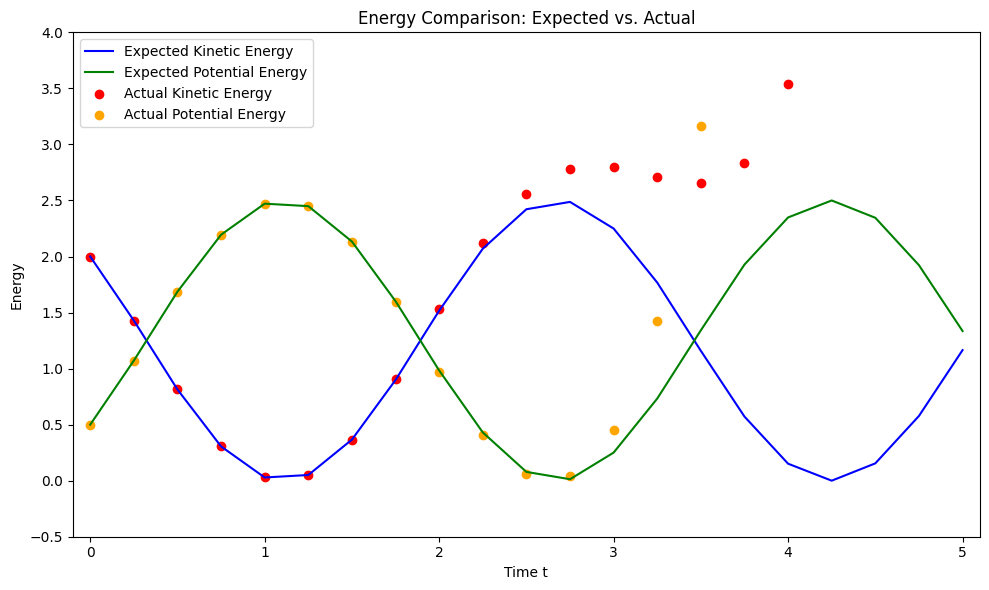

In [15]:
xmin, xmax = -0.1, 5.1
ymin, ymax = -0.5, 4
grid = False
params = {'xmin':xmin, 'xmax':xmax, 'ymin':ymin, 'ymax':ymax, 'grid':grid}

plot_expected_vs_actual(time_range, kinetic_expected, potential_expected, kinetic_actual, potential_actual, params=params)

In [16]:
print_table(time_range, kinetic_expected, potential_expected, kinetic_actual, potential_actual)

|  t   |  Kinetic expected  |  Kinetic actual  |  Potential expected  |  Potential actual)  |
|------|--------------------|------------------|----------------------|---------------------|
|  0   |         2          |        2         |         0.5          |         0.5         |
| 0.25 |      1.42876       |     1.42876      |       1.07124        |       1.07124       |
| 0.5  |      0.813756      |     0.813756     |       1.68624        |       1.68624       |
| 0.75 |      0.305558      |     0.305554     |       2.19444        |       2.19444       |
|  1   |     0.0285924      |    0.0285814     |       2.47141        |       2.47134       |
| 1.25 |     0.0506701      |    0.0507562     |       2.44933        |       2.44892       |
| 1.5  |      0.366386      |     0.367359     |       2.13361        |       2.13191       |
| 1.75 |      0.898441      |     0.903549     |       1.60156        |       1.59631       |
|  2   |      1.51657       |     1.53542      |       0.983